In [44]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.signal import find_peaks

In [2]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR
    / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR
    / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
OPTAA_PATH = DATA_DIR / "CE01ISSM/ce01issm_optaa_processed.nc"
FLORT_PATH = DATA_DIR / "CE01ISSM/ce01issm_flort_processed.nc"

In [7]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
optaa = xr.open_dataset(OPTAA_PATH)
flort = xr.open_dataset(FLORT_PATH)


flort = flort.drop_dims("stats")
optaa_al, flort_al = xr.align(
    optaa.drop_duplicates("time"), flort.drop_duplicates("time")
)

estimated_chloro = (optaa_al.estimated_chlorophyll + flort_al.estimated_chlorophyll) / 2
estimated_chloro = estimated_chloro.resample(time="1D").mean()

## Chlorophyll-Nitrate

Text(0.02, 0.5, 'Estimated Chlorophyll [$\\mathrm{mg \\; m^{-3} }$]')

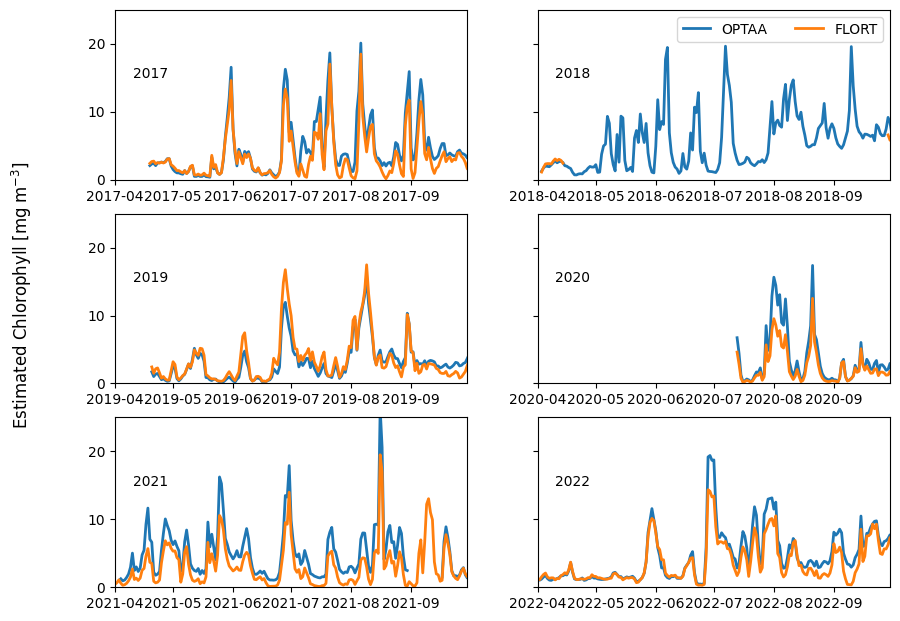

In [4]:
years = np.arange(np.datetime64("2017"), np.datetime64("2024"), np.timedelta64(1, "Y"))
# years_str = [str(year) for year in years]
fig, axs = plt.subplots((len(years) - 1) // 2, 2, figsize=(10, 7.5), sharey=True)
for i, (ts, te, ax) in enumerate(zip(years[:-1], years[1:], axs.flatten())):
    # print(ts, te)
    temp = optaa.where((optaa.time > ts) & (optaa.time < te), drop=True)
    temp = temp.sortby("time")
    temp = temp.resample(time="1D").mean()
    ax.plot(temp.time, temp.estimated_chlorophyll, linewidth=2, label="OPTAA")

    temp = flort.where((flort.time > ts) & (flort.time < te), drop=True)
    temp = temp.sortby("time")
    temp = temp.resample(time="1D").mean()
    ax.plot(temp.time, temp.estimated_chlorophyll, linewidth=2, label="FLORT")

    ax.set_xlim(
        [
            np.datetime64(f"{years[i]!s}-04-01"),
            np.datetime64(f"{years[i]!s}-09-30"),
        ]
    )
    ax.set_ylim([0, 25])
    ax.annotate(f"{ts}", xy=(0.05, 0.6), xytext=(0.05, 0.6), xycoords="axes fraction")


[ax.set_yticks([0, 10, 20]) for ax in axs.T[0]]


axs[0][1].legend(ncols=2)
fig.supylabel("Estimated Chlorophyll [$\\mathrm{mg \\; m^{-3} }$]")

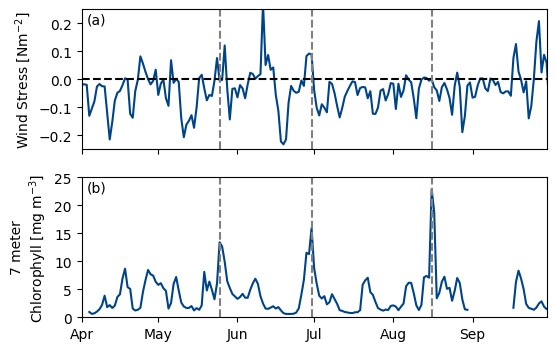

In [97]:
fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

axs[0].plot(wind.time, wind["coare_y"], color="#004488")
axs[0].set_ylim(-0.25, 0.25)
axs[0].axhline(0, color="black", ls="--")

ln1 = axs[1].plot(estimated_chloro.time, estimated_chloro, color="#004488")

axs[1].set_ylim(0, 25)
axs[1].set_xlim(np.datetime64(f"{ts!s}-04-01"), np.datetime64(f"{ts!s}-09-30"))
myFmt = mdates.DateFormatter("%b")
axs[1].xaxis.set_major_locator(mdates.MonthLocator())
axs[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
[
    axs[0].axvline(x.values, c="gray", ls="--")
    for x in estimated_chloro.time[
        find_peaks(estimated_chloro, height=5, distance=1, prominence=10)[0]
    ]
]
[
    axs[1].axvline(x.values, c="gray", ls="--")
    for x in estimated_chloro.time[
        find_peaks(estimated_chloro, height=1, distance=1, prominence=10)[0]
    ]
]
[ax.minorticks_off() for ax in axs]
axs[0].set_ylabel("Wind Stress [$\\mathsf{N m^{-2}}$]")
# axs[1].set_ylabel("Depth Avg.\nNitrate [$\\mathsf{mmol \\; m^{-3}}$]")
axs[1].set_ylabel("7 meter\nChlorophyll [$\\mathsf{mg \\; m^{-3}}$]")
axs[0].annotate(
    "(a)",
    xy=(0.01, 0.9),
    xycoords="axes fraction",
)
axs[1].annotate(
    "(b)",
    xy=(0.01, 0.9),
    xycoords="axes fraction",
)
plt.savefig(
    FIGURES_DIR / "manuscript/chlorophyll-wind.pdf",
    format="pdf",
    bbox_inches="tight",
)

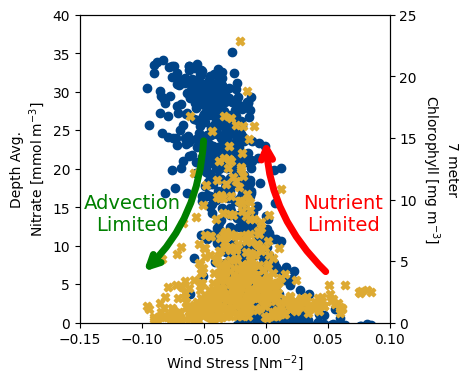

In [102]:
e_c, i_n, c_y = xr.align(
    estimated_chloro, inner_nitrate.nitrate.mean(dim="depth"), wind["w5d"]
)

fig, ax0 = plt.subplots(1, 1, figsize=(4, 4))

ax1 = ax0.twinx()

ax0.scatter(
    c_y,
    i_n,
    color="#004488",
)
ax1.scatter(c_y, e_c, color="#DDAA33", marker="X")
ax0.set_xlim(-0.15, 0.1)
ax0.set_ylim(0, 40)
ax1.set_ylim(0, 25)
ax0.set_xlabel("Wind Stress [$\\mathsf{N m^{-2}}$]")
ax0.set_ylabel("Depth Avg.\nNitrate [$\\mathsf{mmol \\; m^{-3}}$]")
ax1.set_ylabel(
    "7 meter\nChlorophyll [$\\mathsf{mg \\; m^{-3}}$]", rotation=270, labelpad=30
)

ax1.annotate(
    "Nutrient\nLimited",
    xy=(0.85, 0.3),
    xycoords="axes fraction",
    ha="center",
    fontsize=14,
    color="red",
)
ax1.annotate(
    "Advection\nLimited",
    xy=(0.17, 0.3),
    xycoords="axes fraction",
    ha="center",
    color="green",
    fontsize=14,
)
arrow = mpatches.FancyArrowPatch(
    (0.05, 4),
    (-0.0, 15),
    connectionstyle="arc3,rad=-0.2",
    arrowstyle="->",
    mutation_scale=20,
    color="red",
    linewidth=5,
)
ax1.add_patch(arrow)
arrow = mpatches.FancyArrowPatch(
    (-0.05, 15),
    (-0.1, 4),
    connectionstyle="arc3,rad=-0.2",
    arrowstyle="->",
    mutation_scale=20,
    color="green",
    linewidth=5,
)
ax1.add_patch(arrow)
plt.savefig(
    FIGURES_DIR / "manuscript/chlorophyll-nitrate-wind.pdf",
    format="pdf",
    bbox_inches="tight",
)